Asymmetric distillation factory search (Section IV)
  l ∈ [2, 3, 4], k ∈ [1, 2, 3, 4, 5, 6, 7], n ≤ 11
  s_total ∈ [1, 2, 3, 4, 5, 6, 7], s_O ∈ [1, 2, 3, 4, 5, 6, 7], s_S = 1 (fixed)
  l=2 k=1 n=2 s_total=1 s_O=1: |pairs|=3
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=1 s_O=2: |pairs|=3
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=1 s_O=3: |pairs|=3
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=1 s_O=4: |pairs|=3
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=1 s_O=5: |pairs|=3
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=1 s_O=6: |pairs|=3
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=1 s_O=7: |pairs|=3
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=2 s_O=1: |pairs|=2
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=2 s_O=2: |pairs|=2
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=2 s_O=3: |pairs|=2
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=2 s_O=4: |pairs|=2
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=2 s_O=5: |pairs|=2
    → 0 valid in 0.000s
  l=2 k=1 n=2 s_total=2 s_O=6: |pairs

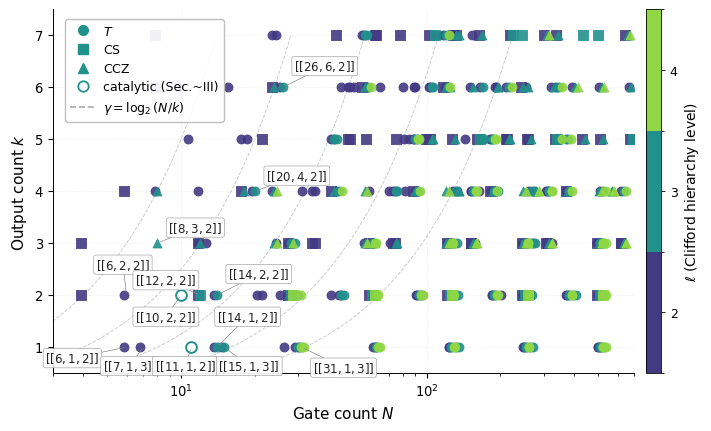

In [53]:
"""
Asymmetric distillation factory search (Section IV).

Search over (l, n, k, s_total, s_O) parameter tuples, with s_S = 1 fixed.
For each tuple, the gate-type set is fully determined by the skip parameters;
the only freedom is the sign assignment on w_O = 0 gates.

Verifies the borrowed-identity condition: Phi(i_O, i_S) ≡ Phi(0, 0) (mod 2pi)
for all (i_O, i_S) — equivalently, Phi is constant.

Output extraction removes all (w, 0) gates with w ∈ W_O ∩ W_total.
The factory is [[N_circuit - sum_w C(k, w), k, d]] where d = 2 for k ≥ 2,
or d = s_total + 1 for k = 1.
"""

from math import comb
from itertools import product
import time


# --- Phase polynomial --------------------------------------------------------

def f_coefficient(i_O, i_S, k, n_minus_k, w_O, w_S):
    """Coefficient [y^w_O z^w_S] of f_{i_O, i_S}(y, z)."""
    coeff_y = sum(
        ((-1) ** j) * comb(i_O, j) * comb(k - i_O, w_O - j)
        for j in range(max(0, w_O - (k - i_O)), min(i_O, w_O) + 1)
    )
    coeff_z = sum(
        ((-1) ** j) * comb(i_S, j) * comb(n_minus_k - i_S, w_S - j)
        for j in range(max(0, w_S - (n_minus_k - i_S)), min(i_S, w_S) + 1)
    )
    return coeff_y * coeff_z


def phi_over_theta_int(i_O, i_S, k, n_minus_k, sigma_dict):
    """Compute Phi(i_O, i_S) / theta as integer (Lemma 7)."""
    total = 0
    for (w_O, w_S), sigma in sigma_dict.items():
        if sigma == 0:
            continue
        c = f_coefficient(i_O, i_S, k, n_minus_k, w_O, w_S)
        total -= sigma * c
    return total


# --- Borrowed-identity condition ---------------------------------------------

def is_borrowed_identity(l, n, k, sigma_dict):
    """
    Theorem 8: Phi(i_O, i_S) ≡ Phi(0, 0) (mod 2^(l+1)) for all (i_O, i_S).
    """
    n_minus_k = n - k
    full_mod = 1 << (l + 1)
    phi_baseline = phi_over_theta_int(0, 0, k, n_minus_k, sigma_dict) % full_mod
    for i_O in range(k + 1):
        for i_S in range(n_minus_k + 1):
            phi = phi_over_theta_int(i_O, i_S, k, n_minus_k, sigma_dict) % full_mod
            if phi != phi_baseline:
                return False
    return True


# --- Output extraction and factory parameters --------------------------------

def n_circuit_count(k, n_minus_k, sigma_dict):
    """Total gates with sigma != 0."""
    return sum(
        comb(k, w_O) * comb(n_minus_k, w_S)
        for (w_O, w_S), sigma in sigma_dict.items()
        if sigma != 0
    )


def extract_factory(k, n_minus_k, sigma_dict, W_O, W_total):
    """
    Compute the residual phase polynomial after extracting (w_O, 0) gates
    with w_O ∈ W_O ∩ W_total.

    Returns:
        (N_paper, residual_phase_dict)
    where residual_phase_dict[i_O] = (Phi'(i_O, 0) - Phi'(0, 0)) / theta mod 2^(l+1)
    """
    N_circuit = n_circuit_count(k, n_minus_k, sigma_dict)
    intersection = set(W_O) & set(W_total)
    n_removed = sum(comb(k, w) for w in intersection if w >= 1)
    N_paper = N_circuit - n_removed
    return N_paper


def residual_phase_at_iO(l, k, n_minus_k, sigma_dict, W_O_int_W_total, i_O):
    """
    Residual Phi'(i_O, 0) after removing (w, 0) gates with w in W_O ∩ W_total.

    The (w, 0) gates contribute -sigma_{w, 0} * A_{i_O}[y^w] * B_0[z^0]
    = -sigma_{w, 0} * A_{i_O}[y^w]  (since B_0[z^0] = 1)
    to Phi(i_O, 0).
    Removing them adds +sigma_{w, 0} * A_{i_O}[y^w] back.
    """
    full_mod = 1 << (l + 1)
    phi_full = phi_over_theta_int(i_O, 0, k, n_minus_k, sigma_dict)
    # The contribution of (w, 0) gates to phi_full
    extracted = 0
    for w in W_O_int_W_total:
        if w < 1:
            continue
        sigma = sigma_dict.get((w, 0), 0)
        if sigma == 0:
            continue
        # Contribution was -sigma * A[y^w] * B[z^0] = -sigma * A[y^w]
        # Removing it adds +sigma * A[y^w]
        coeff_y = sum(
            ((-1) ** j) * comb(i_O, j) * comb(k - i_O, w - j)
            for j in range(max(0, w - (k - i_O)), min(i_O, w) + 1)
        )
        extracted -= -sigma * coeff_y  # subtract the contribution
    return (phi_full + extracted) % full_mod


def classify_output(l, k, n_minus_k, sigma_dict, W_O_int_W_total):
    """
    Compute residual phase Phi'(i_O, 0) - Phi'(0, 0) mod 2^(l+1)
    for i_O = 0, ..., k. Identify the output magic state from the
    polynomial form.
    """
    full_mod = 1 << (l + 1)
    half_mod = full_mod // 2
    
    def center(x):
        return ((x + half_mod) % full_mod) - half_mod
    
    phi_residual = [
        residual_phase_at_iO(l, k, n_minus_k, sigma_dict, W_O_int_W_total, i_O)
        for i_O in range(k + 1)
    ]
    # Subtract baseline
    phi_diff = [(p - phi_residual[0]) % full_mod for p in phi_residual]
    phi_diff = [center(p) for p in phi_diff]
    
    if all(p == 0 for p in phi_diff):
        return "trivial", phi_diff
    
    # Find lowest-order constant finite difference
    diffs = phi_diff[:]
    for degree in range(1, k + 2):
        diffs = [center(diffs[i+1] - diffs[i]) for i in range(len(diffs) - 1)]
        if all(d == diffs[0] for d in diffs) and diffs[0] != 0:
            return f"deg{degree}", phi_diff

    return "trivial", phi_diff  # or "non-poly" if you want to distinguish


# --- Skip-parameter gate-set construction ------------------------------------

def W_AP(n, s):
    """Arithmetic progression {1, 1+s, 1+2s, ...} ∩ {1, ..., n}."""
    return [w for w in range(1, n + 1) if (w - 1) % s == 0]


def build_gate_set(k, n_minus_k, s_total, s_O):
    """Return (allowed_pairs, W_total, W_O) given skip parameters with s_S = 1."""
    n = k + n_minus_k
    W_total = set(W_AP(n, s_total))
    W_O = set([0] + W_AP(k, s_O))
    W_S = set(range(0, n_minus_k + 1))  # s_S = 1

    pairs = []
    for w_O in W_O:
        if w_O > k:
            continue
        for w_S in W_S:
            if w_S > n_minus_k:
                continue
            if w_O + w_S in W_total and w_O + w_S >= 1:
                pairs.append((w_O, w_S))
    return sorted(pairs), W_total, W_O


# --- Sign-assignment search --------------------------------------------------

def find_valid_signs(l, n, k, pairs):
    """
    Try all-positive first. If it fails, enumerate σ ∈ {-1, +1} for
    w_O = 0 pairs (others fixed at +1).

    Returns: list of valid sigma_dicts.
    """
    valid_configs = []

    sigma_all_pos = {pair: 1 for pair in pairs}
    if is_borrowed_identity(l, n, k, sigma_all_pos):
        valid_configs.append(dict(sigma_all_pos))

    check_only_pairs = [p for p in pairs if p[0] == 0]
    if not check_only_pairs:
        return valid_configs

    for sign_choice in product([-1, 1], repeat=len(check_only_pairs)):
        if all(s == 1 for s in sign_choice):
            continue
        sigma_dict = {pair: 1 for pair in pairs}
        for pair, sign in zip(check_only_pairs, sign_choice):
            sigma_dict[pair] = sign
        if is_borrowed_identity(l, n, k, sigma_dict):
            valid_configs.append(dict(sigma_dict))

    return valid_configs


# --- Main search loop --------------------------------------------------------

def search_all(L_RANGE, K_RANGE, N_MAX, S_TOTAL_RANGE, S_O_RANGE, verbose=True):
    all_results = []
    timing = {}
    for l in L_RANGE:
        for k in K_RANGE:
            for n in range(k + 1, N_MAX + 1):
                n_minus_k = n - k
                for s_total in S_TOTAL_RANGE:
                    for s_O in S_O_RANGE:
                        pairs, W_total, W_O = build_gate_set(
                            k, n_minus_k, s_total, s_O
                        )
                        if not pairs:
                            continue
                        if verbose:
                            print(f"  l={l} k={k} n={n} s_total={s_total} s_O={s_O}: "
                                  f"|pairs|={len(pairs)}", flush=True)
                        t_start = time.time()
                        valid_configs = find_valid_signs(l, n, k, pairs)
                        t_elapsed = time.time() - t_start
                        timing[(l, k, n, s_total, s_O)] = {
                            "time": t_elapsed,
                            "n_pairs": len(pairs),
                            "found": len(valid_configs),
                        }
                        if verbose:
                            print(f"    → {len(valid_configs)} valid in "
                                  f"{t_elapsed:.3f}s", flush=True)
                        for sigma_dict in valid_configs:
                            N_paper = extract_factory(
                                k, n_minus_k, sigma_dict, W_O, W_total
                            )
                            # Distance: d = 2 for k >= 2; d = s_total + 1 for k = 1
                            d = (s_total + 1) if k == 1 else 2
                            W_O_int_W_total = set(W_O) & set(W_total)
                            output_type, phi_diff = classify_output(
                                l, k, n_minus_k, sigma_dict, W_O_int_W_total
                            )
                            all_results.append({
                                "l": l, "n": n, "k": k,
                                "s_total": s_total, "s_O": s_O,
                                "N": N_paper, "d": d,
                                "output": output_type,
                                "phi_diff": phi_diff,
                                "W_total": sorted(W_total),
                                "W_O": sorted(W_O),
                                "pairs": pairs,
                                "sigma": sigma_dict,
                            })
    return all_results, timing


# --- Recovery check ----------------------------------------------------------

TARGETS = [
    {"name": "[[6, 1, 2]] (Sec II all-weights, l=2)",
     "l": 2, "n": 3, "k": 1, "N": 6, "d": 2},
    {"name": "[[7, 1, 3]] (Steane / RM, l=2)",
     "l": 2, "n": 4, "k": 1, "N": 7, "d": 3},
    {"name": "[[6, 2, 2]] (H-code, l=2)",
     "l": 2, "n": 4, "k": 2, "N": 6, "d": 2},
    {"name": "[[14, 1, 2]] (Sec II all-weights, l=3)",
     "l": 3, "n": 4, "k": 1, "N": 14, "d": 2},
    {"name": "[[15, 1, 3]] (RM, l=3)",
     "l": 3, "n": 5, "k": 1, "N": 15, "d": 3},
    {"name": "[[12, 2, 2]] (Sec II derivative, l=3)",
     "l": 3, "n": 4, "k": 2, "N": 12, "d": 2},
    {"name": "[[14, 2, 2]] (BH k=2, l=3)",
     "l": 3, "n": 5, "k": 2, "N": 14, "d": 2},
    {"name": "[[8, 3, 2]] (cube, l=3)",
     "l": 3, "n": 4, "k": 3, "N": 8, "d": 2},
    {"name": "[[20, 4, 2]] (BH k=4, l=3)",
     "l": 3, "n": 7, "k": 4, "N": 20, "d": 2},
    {"name": "[[26, 6, 2]] (BH k=6, l=3, stretch)",
     "l": 3, "n": 9, "k": 6, "N": 26, "d": 2},
]


def recovery_check(results):
    print("\n" + "=" * 60)
    print("Recovery check")
    print("=" * 60)
    for t in TARGETS:
        matches = [
            r for r in results
            if r["l"] == t["l"] and r["n"] == t["n"]
            and r["k"] == t["k"] and r["N"] == t["N"] and r["d"] == t["d"]
        ]
        status = f"✓ found ({len(matches)} matches)" if matches else "✗ NOT FOUND"
        print(f"  {t['name']}: {status}")
        if matches:
            m = matches[0]
            active = [(p, m["sigma"][p]) for p in m["pairs"] if m["sigma"][p] != 0]
            print(f"    s_total={m['s_total']}, s_O={m['s_O']}, "
                  f"output={m['output']}")
            print(f"    Active gates (sigma != 0): {active}")


# --- Output ------------------------------------------------------------------

def print_summary(results):
    print(f"\nTotal valid factories found: {len(results)}")
    seen = set()
    print(f"\n{'l':<3}{'k':<4}{'N':<5}{'d':<3}{'n':<4}{'output':<10}"
          f"{'ent.':<6}{'s_t':<5}{'s_O':<5}")
    print("-" * 56)
    for r in sorted(results, key=lambda r: (r["l"], r["k"], r["d"], r["N"], r["n"])):
        key = (r["l"], r["k"], r["N"], r["d"], r["output"])
        if key in seen:
            continue
        seen.add(key)
        if r["output"] == "trivial":
            ent_label = "—"
        elif is_entangled_output(r["output"]):
            ent_label = "ent"
        else:
            ent_label = "unent"
        print(f"{r['l']:<3}{r['k']:<4}{r['N']:<5}{r['d']:<3}{r['n']:<4}"
              f"{r['output']:<10}{ent_label:<6}{r['s_total']:<5}{r['s_O']:<5}")

def is_entangled_output(output_type):
    if output_type == "trivial":
        return False
    degree = int(output_type.replace("deg", ""))
    return degree >= 2
# --- Main --------------------------------------------------------------------

if __name__ == "__main__":
    L_RANGE = [2, 3, 4]
    K_RANGE = [1, 2, 3, 4, 5, 6, 7]
    N_MAX = 11
    S_TOTAL_RANGE = [1, 2, 3, 4, 5, 6, 7]
    S_O_RANGE = [1, 2, 3, 4, 5, 6, 7]

    print("=" * 60)
    print("Asymmetric distillation factory search (Section IV)")
    print(f"  l ∈ {L_RANGE}, k ∈ {K_RANGE}, n ≤ {N_MAX}")
    print(f"  s_total ∈ {S_TOTAL_RANGE}, s_O ∈ {S_O_RANGE}, s_S = 1 (fixed)")
    print("=" * 60)

    all_results, timing = search_all(
        L_RANGE, K_RANGE, N_MAX, S_TOTAL_RANGE, S_O_RANGE,
        verbose=True
    )

    print_summary(all_results)
    recovery_check(all_results)



"""
Figure 3: asymmetric distillation factory coverage.

Two-column-spanning figure with a discrete viridis colorbar on the
side (matching the symmetric/sequential figure conventions). The
legend on top shows only marker shapes (output types) and the
catalytic / gamma-line entries. ell is encoded by color, read off
from the right-hand colorbar.
"""

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np


# --- Colors and markers ------------------------------------------------------
def _discrete_l_palette(ls):
    """Discrete viridis matching seq_fixed.py / Fig. 2 conventions."""
    base = plt.get_cmap("viridis")
    n = len(ls)
    cmap = ListedColormap([base((i + 0.5) / n) for i in range(n)])
    bounds = [ls[0] - 0.5] + [l + 0.5 for l in ls]
    norm = BoundaryNorm(bounds, cmap.N)
    return cmap, norm, bounds


L_VALUES = [2, 3, 4]
CMAP, NORM, BOUNDS = _discrete_l_palette(L_VALUES)
COLOR_L = {l: CMAP(NORM(l)) for l in L_VALUES}

MARKER_OUT = {"deg1": "o", "deg2": "s", "deg3": "^"}

# --- Helper: extract from search records -------------------------------------
def extract_unique_factories(all_results):
    """Extract unique (N, k, l, output) tuples, excluding trivial."""
    seen = set()
    factories = []
    for r in all_results:
        if r["output"] == "trivial":
            continue
        key = (r["N"], r["k"], r["l"], r["output"])
        if key in seen:
            continue
        seen.add(key)
        factories.append(key)
    return factories


DEFAULT_CATALYTIC = [
    (10, 2, 3, "T",   "Sec III catalysis"),
    (11, 1, 3, "T",   "Sec III catalysis"),
]

DEFAULT_LANDMARKS = [
    (6,  2, "$[[6,2,2]]$",   "data", (4.5, 2.5)),
    (6,  1, "$[[6,1,2]]$",   "data", (2.8, 0.7)),
    (7,  1, "$[[7,1,3]]$",   "data", (4.8, 0.55)),
    (8,  3, "$[[8,3,2]]$",   "offset points", (8, 8)),
    (10, 2, "$[[10,2,2]]$",  "data", (6.5, 1.5)),
    (11, 1, "$[[11,1,2]]$",  "data", (7.8, 0.55)),
    (12, 2, "$[[12,2,2]]$",  "data", (6.5, 2.2)),
    (14, 1, "$[[14,1,2]]$",  "data", (14, 1.5)),
    (14, 2, "$[[14,2,2]]$",  "offset points", (8, 12)),
    (15, 1, "$[[15,1,3]]$",  "data", (14.2, 0.55)),
    (20, 4, "$[[20,4,2]]$",  "offset points", (8, 8)),
    (26, 6, "$[[26,6,2]]$",  "offset points", (8, 12)),
    (31, 1, "$[[31,1,3]]$",  "offset points", (8, -18)),
]

def make_figure(asym_captures,
                catalytic=None,
                landmarks=None,
                out_path="code_IV"):
    if catalytic is None:
        catalytic = DEFAULT_CATALYTIC
    if landmarks is None:
        landmarks = DEFAULT_LANDMARKS

    unknown_outputs = ({out for _, _, _, out in asym_captures}
                       - set(MARKER_OUT))
    unknown_ls = ({l for _, _, l, _ in asym_captures}
                  - set(COLOR_L))
    if unknown_outputs:
        print(f"warning: unknown output types {unknown_outputs} -- "
              f"will be skipped")
    if unknown_ls:
        print(f"warning: unknown l values {unknown_ls} -- "
              f"will plot as gray")

    # ---- Figure -------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)

    # ---- gamma-isolines -----------------------------------------------------
    gamma_levels = [1, 2, 3, 4, 5]
    k_range = np.linspace(0.7, 7, 200)
    for gamma in gamma_levels:
        N_iso = k_range * (2 ** gamma)
        ax.plot(N_iso, k_range, "--", color="#cccccc",
                linewidth=0.7, zorder=0)
        x_label = 600
        k_label = x_label / (2 ** gamma)
        if 0.5 <= k_label <= 7.5:
            ax.text(x_label, k_label, rf"$\gamma = {gamma}$",
                    fontsize=8, color="#888888",
                    ha="right", va="bottom", rotation=-15)

    # ---- Asymmetric captures (filled markers) -------------------------------
    def jitter(N, l):
        return N * (1 + 0.025 * (l - 3))

    drawable = [(N, k, l, out) for (N, k, l, out) in asym_captures
                if out in MARKER_OUT]

    for N, k, l, out in drawable:
        color = COLOR_L.get(l, "#666666")
        marker = MARKER_OUT[out]
        x = jitter(N, l)
        ax.scatter(x, k, marker=marker, s=42, c=[color],
                   edgecolors=color, linewidths=0.6, alpha=0.9,
                   zorder=3)

    # ---- Catalytic captures (open markers) ----------------------------------
    for entry in catalytic:
        N, k, l, out = entry[:4]
        color = COLOR_L.get(l, "#666666")
        marker = MARKER_OUT.get(out, "o")
        ax.scatter(N, k, marker=marker, s=60, facecolors="white",
                   edgecolors=color, linewidths=1.4, zorder=4)

    # ---- Landmark annotations (with white box + connector) ------------------
    for N, k, label, textcoords, xytext in landmarks:
        ax.annotate(
            label, (N, k),
            xytext=xytext, textcoords=textcoords,
            fontsize=8.5, color="#222222", zorder=6,
            bbox=dict(boxstyle="round,pad=0.18",
                      fc="white", ec="#888", lw=0.4, alpha=0.92),
            arrowprops=dict(arrowstyle="-", color="#888",
                            lw=0.5, shrinkA=0, shrinkB=2),
        )

    # ---- Discrete ell colorbar (sidebar) ------------------------------------
    sm = plt.cm.ScalarMappable(norm=NORM, cmap=CMAP)
    sm.set_array([l for _, _, l, _ in drawable])
    cbar = fig.colorbar(
        sm, ax=ax, boundaries=BOUNDS, ticks=L_VALUES,
        spacing="proportional", pad=0.02, fraction=0.045, aspect=24,
    )
    cbar.set_label(r"$\ell$ (Clifford hierarchy level)", fontsize=10)
    cbar.ax.tick_params(labelsize=9, width=0.6, length=3)
    cbar.outline.set_linewidth(0.6)

    # ---- Legend (output shapes + catalytic + gamma line) --------------------
    l3_color = COLOR_L[3]

    legend_elements = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=l3_color, markeredgecolor=l3_color,
               markersize=7, label=r"$T$"),
        Line2D([0], [0], marker="s", color="w",
               markerfacecolor=l3_color, markeredgecolor=l3_color,
               markersize=7, label=r"$\mathrm{CS}$"),
        Line2D([0], [0], marker="^", color="w",
               markerfacecolor=l3_color, markeredgecolor=l3_color,
               markersize=7, label=r"$\mathrm{CCZ}$"),
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor="white", markeredgecolor=l3_color,
               markersize=7.5, markeredgewidth=1.3,
               label=r"catalytic (Sec.~III)"),
        Line2D([0], [0], color="#aaaaaa", linestyle="--", linewidth=1.2,
               label=r"$\gamma = \log_2(N/k)$"),
        ]
    ax.legend(
        handles=legend_elements, loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
        frameon=True, framealpha=0.92, edgecolor="#bbbbbb",
        fontsize=9, ncol=1,
        labelspacing=0.45, handletextpad=0.6, borderpad=0.45,
    )

    # ---- Axes ---------------------------------------------------------------
    ax.set_xscale("log")
    ax.set_xlim(3, 700)
    ax.set_ylim(0.5, 7.5)
    ax.set_xlabel(r"Gate count $N$", fontsize=11)
    ax.set_ylabel(r"Output count $k$", fontsize=11)
    ax.set_yticks([1, 2, 3, 4, 5, 6, 7])
    ax.tick_params(axis="both", labelsize=9.5)
    ax.grid(True, linestyle=":", linewidth=0.4, alpha=0.4, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)

    fig.savefig(f"{out_path}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{out_path}.pdf", bbox_inches="tight")
    print(f"saved {out_path}.{{png,pdf}}")
    return fig


if __name__ == "__main__":
    try:
        all_results  # noqa: F821
    except NameError:
        raise SystemExit(
            "all_results is not defined. Either run this after your "
            "search code in the same session, or import the search "
            "results before calling make_figure("
            "extract_unique_factories(all_results))."
        )

    asym_captures = extract_unique_factories(all_results)  # noqa: F821
    make_figure(asym_captures)